# Schema Refinement Analysis
Reproduces the refinement analysis from Appendix of the paper:
> **Beyond Black-Box Labels: Interpretable Criteria for Diagnosing Subjective NLP Tasks**

Compares the original schema (q01-q09) with the refined schema 
(q01-q09 + q10 + q11) to show how criterion decomposition shifts 
instability patterns.

**q10** (formerly q05a) = explicit credibility markers only  
**q11** = perceived quality + reputation (merged q05b + q06)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────
TENSOR_NPY  = Path("../data/tensors/run_2026-04-13_14-00_FULL_AGGREGATED/tensor_raw_4700.npy")
MAPPING_CSV = Path("../data/tensors/run_2026-04-13_14-00_FULL_AGGREGATED/mapping_sentences.csv")

# ── Constants ─────────────────────────────────────────────────────
# Full schema including refinement criteria
CRITERIA_ALL = [
    "q01_CostReduction",
    "q02_OperationalEfficiency",
    "q03_OrganizationalImpact",
    "q04_UserWellbeing",
    "q05_ReputationRecognition",
    "q06_PerceivedQuality",
    "q07_RegulatoryCompliance",
    "q08_RiskPrevention",
    "q09_MandatoryRequirement",
    "q10_ExplicitCredibility",    # q05a refined
    "q11_PerceivedPositive",      # q05b + q06 merged
]

SHORT_NAMES_ALL = ["q1","q2","q3","q4","q5","q6","q7","q8","q9","q10","q11"]
SHORT_NAMES_9   = ["q1","q2","q3","q4","q5","q6","q7","q8","q9"]

# Main panel: 5 models excluding Gemini
A = 5
t = 1

print("Setup complete.")

Setup complete.


## 2. Load tensor

In [2]:
# ── Load full tensor (all 11 criteria, exclude Gemini) ────────────
tensor = np.load(TENSOR_NPY)
tensor_main = tensor[:, :11, 1:]  # (4700, 11, 5)

# Drop missing
valid_mask  = np.all(tensor_main != -1, axis=(1,2))
tensor_main = tensor_main[valid_mask]
N           = tensor_main.shape[0]

# Vote counts
vote_counts = tensor_main.sum(axis=2)  # (N, 11)
focus_sets  = vote_counts >= t          # (N, 11)

print(f"Tensor shape : {tensor_main.shape}")
print(f"Valid sentences: {N}")

Tensor shape : (4696, 11, 5)
Valid sentences: 4696


## 3. Stability metrics for all 11 criteria

In [3]:
# ── Compute stability metrics ─────────────────────────────────────
results = []
for i, name in enumerate(CRITERIA_ALL):
    focus_mask = focus_sets[:, i]
    n_focus    = focus_mask.sum()
    
    if n_focus == 0:
        continue
    
    votes_focused = vote_counts[focus_mask, i]
    
    act  = n_focus / N
    NT   = ((votes_focused == 2) | (votes_focused == 3)).sum() / n_focus * 100
    AS   = ((votes_focused == 4) | (votes_focused == 1)).sum() / n_focus * 100
    UY   = (votes_focused == 5).sum() / n_focus * 100
    
    results.append({
        "criterion" : name,
        "short"     : SHORT_NAMES_ALL[i],
        "Act1"      : round(act * 100, 1),
        "NT"        : round(NT, 1),
        "AS"        : round(AS, 1),
        "UY"        : round(UY, 1),
        "n_focus"   : int(n_focus),
        "is_refined": i >= 9,  # q10, q11
    })

df_stab = pd.DataFrame(results)
print(df_stab[["short","Act1","NT","AS","UY","n_focus"]].to_string(index=False))

short  Act1   NT   AS   UY  n_focus
   q1   2.8 22.9 45.8 31.3      131
   q2   9.4 28.2 43.3 28.4      443
   q3  12.6 28.9 44.8 26.4      592
   q4   9.8 35.8 48.3 15.9      458
   q5  17.6 34.0 52.3 13.7      826
   q6  24.1 23.3 31.9 44.9     1130
   q7   5.8 25.6 44.7 29.7      273
   q8  14.1 27.8 36.9 35.3      662
   q9  10.3 38.2 41.7 20.1      482
  q10   1.8 28.6 54.8 16.7       84
  q11  24.1 32.0 33.9 34.1     1130


## 4. Figure: Stability landscape (original + refined criteria)

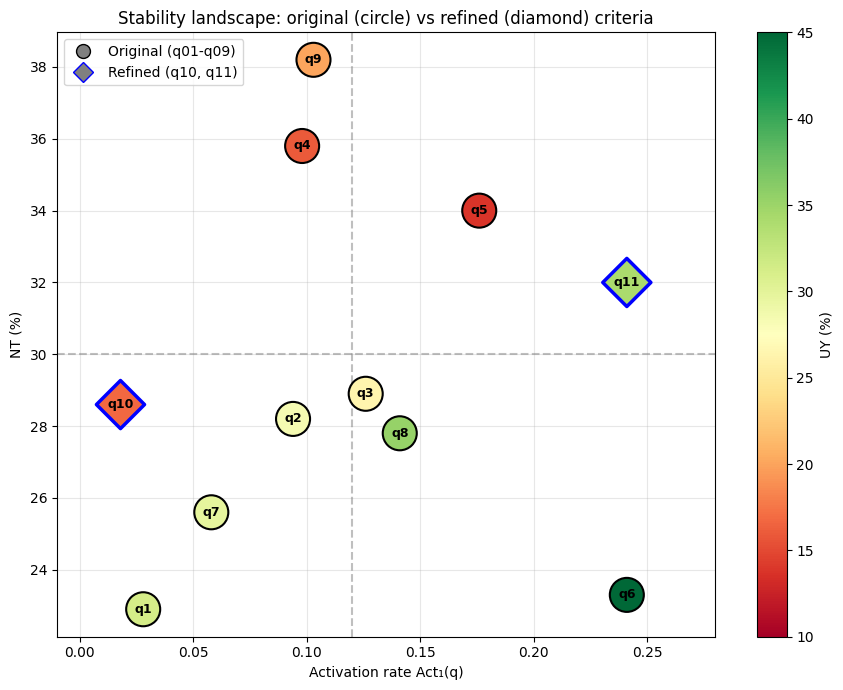

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

# Separate original and refined
df_orig    = df_stab[~df_stab['is_refined']]
df_refined = df_stab[df_stab['is_refined']]

# Plot original criteria
sc1 = ax.scatter(
    df_orig['Act1'] / 100,
    df_orig['NT'],
    c=df_orig['UY'],
    cmap='RdYlGn',
    s=600,
    edgecolors='black',
    linewidths=1.5,
    zorder=3,
    vmin=10, vmax=45,
)

# Plot refined criteria (different marker)
sc2 = ax.scatter(
    df_refined['Act1'] / 100,
    df_refined['NT'],
    c=df_refined['UY'],
    cmap='RdYlGn',
    s=600,
    edgecolors='blue',
    linewidths=2.5,
    marker='D',  # diamond for refined
    zorder=4,
    vmin=10, vmax=45,
)

# Labels inside circles
for _, row in df_stab.iterrows():
    ax.annotate(
        row['short'],
        (row['Act1']/100, row['NT']),
        ha='center', va='center',
        fontsize=9, fontweight='bold',
        zorder=5
    )

# Quadrant lines
ax.axvline(x=0.12, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=30,   color='gray', linestyle='--', alpha=0.5)

# # Quadrant labels
# ax.text(0.01, 39.5, "Unstable\n& Rare",     fontsize=9, color='gray', style='italic')
# ax.text(0.14, 39.5, "Unstable\n& Frequent", fontsize=9, color='gray', style='italic')
# ax.text(0.01, 22,   "Stable\n& Rare",       fontsize=9, color='gray', style='italic')
# ax.text(0.14, 22,   "Stable\n& Frequent",   fontsize=9, color='gray', style='italic')

plt.colorbar(sc1, ax=ax, label="UY (%)")
ax.set_xlabel("Activation rate Act₁(q)")
ax.set_ylabel("NT (%)")
ax.set_title("Stability landscape: original (circle) vs refined (diamond) criteria")
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.01, 0.28)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=10, label='Original (q01-q09)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='gray',
           markeredgecolor='blue', markersize=10, label='Refined (q10, q11)'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig("../results/figure_stability_refined.pdf", dpi=150, bbox_inches='tight')
plt.show()

## 5. Conditional overlap matrix (all 11 criteria)

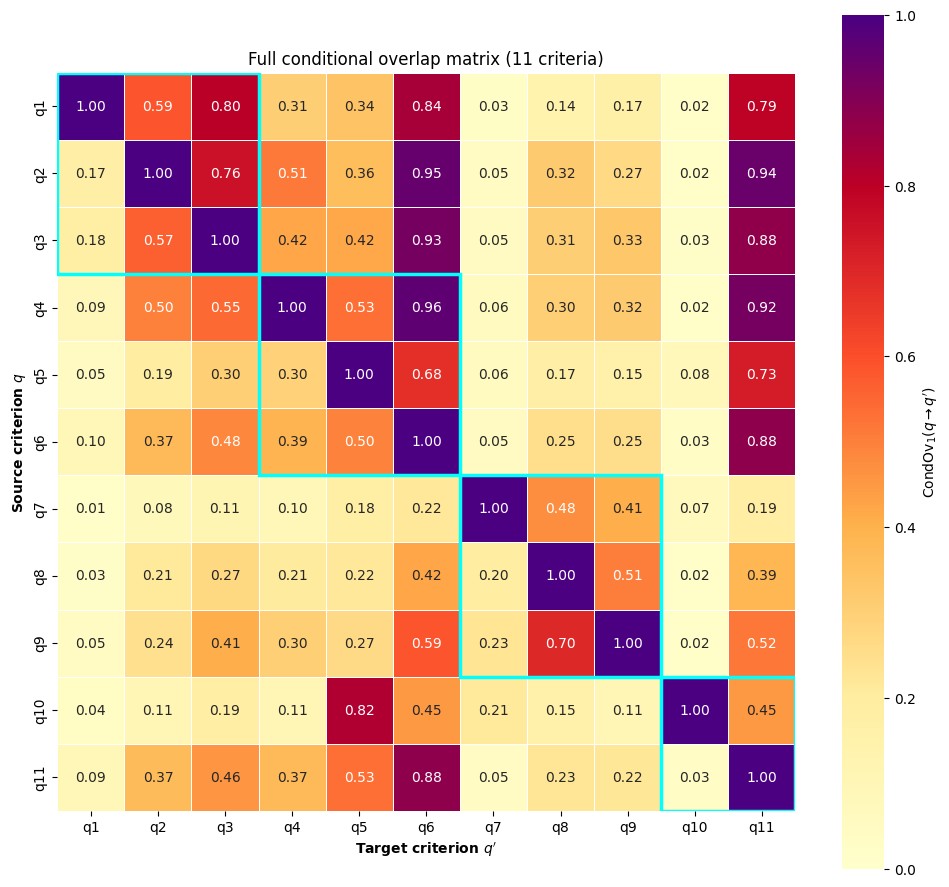

In [7]:
# ── Compute directed conditional overlap ──────────────────────────
N_ALL    = 11
cond_ov  = np.zeros((N_ALL, N_ALL))

for q in range(N_ALL):
    for qp in range(N_ALL):
        omega_q  = focus_sets[:, q]
        omega_qp = focus_sets[:, qp]
        denom    = omega_q.sum()
        if denom > 0:
            cond_ov[q, qp] = (omega_q & omega_qp).sum() / denom

# ── Plot ──────────────────────────────────────────────────────────
# Custom colormap
colors_cmap = ["#FFFFCC","#FFEDA0","#FEB24C","#FC4E2A","#BD0026","#4B0082"]
cmap = LinearSegmentedColormap.from_list("custom", colors_cmap)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    cond_ov,
    ax=ax,
    cmap=cmap,
    vmin=0, vmax=1,
    xticklabels=SHORT_NAMES_ALL,
    yticklabels=SHORT_NAMES_ALL,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"label": r"CondOv$_1(q \rightarrow q')$"}
)

# Category borders (original 3 + 2 refined)
# c1: 0-2, c2: 3-5, c3: 6-8, refined: 9-10
for pos, size in [(0,3),(3,3),(6,3),(9,2)]:
    ax.add_patch(plt.Rectangle(
        (pos, pos), size, size,
        fill=False, edgecolor='cyan', linewidth=2.5, zorder=3
    ))

ax.set_xlabel("Target criterion $q'$", fontweight='bold')
ax.set_ylabel("Source criterion $q$",  fontweight='bold')
ax.set_title("Full conditional overlap matrix (11 criteria)")
plt.tight_layout()
plt.savefig("../results/appendix_overlap_refined.pdf", dpi=150, bbox_inches='tight')
plt.show()